In [1]:
# Set up environment
from pyprojroot import here
import zarr
import os
import pandas as pd
import os
import dask.array as da
import dask
from tqdm import tqdm
import yaml
from pathlib import Path
import numpy as np
import gcsfs
import numba
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import collections
import logging
import xarray as xr
# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

%run {here()}/setup.ipynb


gcs = init_gcs()

Loading BokehJS ...

conda_prefix:  /home/conda/global/envs/global-mgenv-7.1.0
current_environment:  global/global-mgenv-7.1.0


/home/conda/global/8fa1d3231a922509a6e528f7afc800c68757ad8365d7e32cae8db25e5aeae990-20250320-111029-528577-86-mgenv-7.1.0/lib/python3.12/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [2]:
# Set up Dask cluster
from dask_gateway import Gateway
gateway = Gateway()

conda_prefix = os.environ['CONDA_PREFIX']
current_environment = re.sub("/home/conda/(.+)/envs/(.+)","\\1/\\2", conda_prefix)
# Create cluster
cluster = gateway.new_cluster(
        profile="highmem",
        conda_environment = current_environment,
)
cluster.scale(60)

client = cluster.get_client()
client

# Define sample sets
sample_sets = [
    "1278-VO-TH-KOBYLINSKI-VMF00153",
    "1276-AD-BD-ALAM-VMF00156",
    "1277-VO-KH-WITKOWSKI-VMF00151",
    "1277-VO-KH-WITKOWSKI-VMF00183",
]

# Get all contigs in the genome
genome_path = "gs://vo_adir_release/reference/genome/AdirusWRAIR2/VectorBase-56_AdirusWRAIR2_Genome.zarr"
genome_store = gcs.get_mapper(genome_path)
genome = zarr.open_consolidated(genome_store)

contig_lengths = {
    k: len(genome[k]) for k in genome
}


In [3]:

# Zarr paths
sample_set_zarr_url_template = "vo_adir_production_us_central1/v1.x/staging/snp_genotypes/all/{sample_set}"
qc_stat_zarr_url = 'gs://vo_adir_production_us_central1/accessibility_summary_stats/v1.0/snp_accessibility_filtering.zarr'
metadata_url = "gs://vo_adir_production_us_central1/v1.x/staging/metadata/general/{sample_set}/samples.meta.csv"

In [4]:
def open_calldata_array(v, contig):
    arrays = []
    for sample_set in sample_sets:
        url = sample_set_zarr_url_template.format(sample_set=sample_set)
        root = open_gcs_zarr(gcs_url=url, gcs=gcs)
        array = root[f"{contig}/calldata/{v}"]
        arrays.append(array)

    return da.concatenate(arrays, axis=1)


def load_metadata():
    dfs = []
    for sample_set in sample_sets:
        d = pd.read_csv(metadata_url.format(sample_set = sample_set))
        dfs.append(d)
    return pd.concat(dfs)

# Get genotypes from the longest contig, subset to samples passing QC and passing filters
def load_gts(chrom):
    qc_store = gcs.get_mapper(qc_stat_zarr_url)
    qc_data = zarr.open(qc_store)
    gt = allel.GenotypeDaskArray(open_calldata_array('GT', chrom))
    return gt.compress(qc_data[f"{chrom}/sc_filter_pass"][:], axis=0)

def return_n_alt(gt_block, n=50_000):
    ac = gt_block.count_alleles()
    flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)
    gf = gt.compress(flt, axis=0)
    gn = gf.to_n_alt().compute()
    vidx = np.random.choice(gn.shape[0], n, replace=False)
    vidx.sort()
    gnr = gn.take(vidx, axis=0)
    return gnr


In [5]:
%%time
# Select GTs, run PCA
gt = load_gts("KB672490") # load GTs passing site and sample filters
n_a = return_n_alt(gt) # calculate n_ alt from biallelic sites with a mac > 1
coords, model = allel.pca(n_a, n_components=10, scaler='patterson') # calculate PCA

/home/conda/global/8fa1d3231a922509a6e528f7afc800c68757ad8365d7e32cae8db25e5aeae990-20250320-111029-528577-86-mgenv-7.1.0/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 69.33 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/conda/global/8fa1d3231a922509a6e528f7afc800c68757ad8365d7e32cae8db25e5aeae990-20250320-111029-528577-86-mgenv-7.1.0/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 69.34 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for mor

CPU times: user 51.5 s, sys: 4.94 s, total: 56.5 s
Wall time: 1min 44s


In [6]:
df_samples = load_metadata()

/home/conda/global/8fa1d3231a922509a6e528f7afc800c68757ad8365d7e32cae8db25e5aeae990-20250320-111029-528577-86-mgenv-7.1.0/lib/python3.12/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [7]:
# Define pops
populations = df_samples.country.unique()

country_colors = {
    'Thailand': '#377eb8',
    'Bangladesh': '#ff7f00',
    'Cambodia': '#4daf4a',
}



In [8]:
df_samples['count'] = 1  # Add a dummy column
grouped = df_samples.groupby(['country']).agg({
    'count': 'sum'
}).reset_index()

grouped.columns = ['Country', 'Total Count']

# Display nicely
print(grouped.to_string(index=False))

   Country  Total Count
Bangladesh           47
  Cambodia          274
  Thailand          219


In [9]:
def plot_pca_coords(coords, model, pc1, pc2, ax, sample_population, colourdict):
    sns.despine(ax=ax, offset=5)
    x = coords[:, pc1]
    y = coords[:, pc2]
    for pop in populations:
        flt = (sample_population == pop)
        ax.plot(x[flt], y[flt], marker='o', linestyle=' ', color=colourdict[pop], 
                label=pop, markersize=10, mec='k', mew=.5)
    ax.set_xlabel('PC%s (%.1f%%)' % (pc1+1, model.explained_variance_ratio_[pc1]*100))
    ax.set_ylabel('PC%s (%.1f%%)' % (pc2+1, model.explained_variance_ratio_[pc2]*100))
    

def fig_pca(coords, model, title, colourdict, df_samples, sample_population=None):
    if sample_population is None:
        sample_population = df_samples.country.values
    else:
        sample_population = df_samples.sample_population.values
    # plot coords for PCs 1 vs 2, 3 vs 4
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 2, 1)
    plot_pca_coords(coords, model, 0, 1, ax, sample_population, colourdict=colourdict)
    ax = fig.add_subplot(1, 2, 2)
    plot_pca_coords(coords, model, 2, 3, ax, sample_population, colourdict=colourdict)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
    fig.suptitle(title, y=1.02)
    fig.tight_layout()

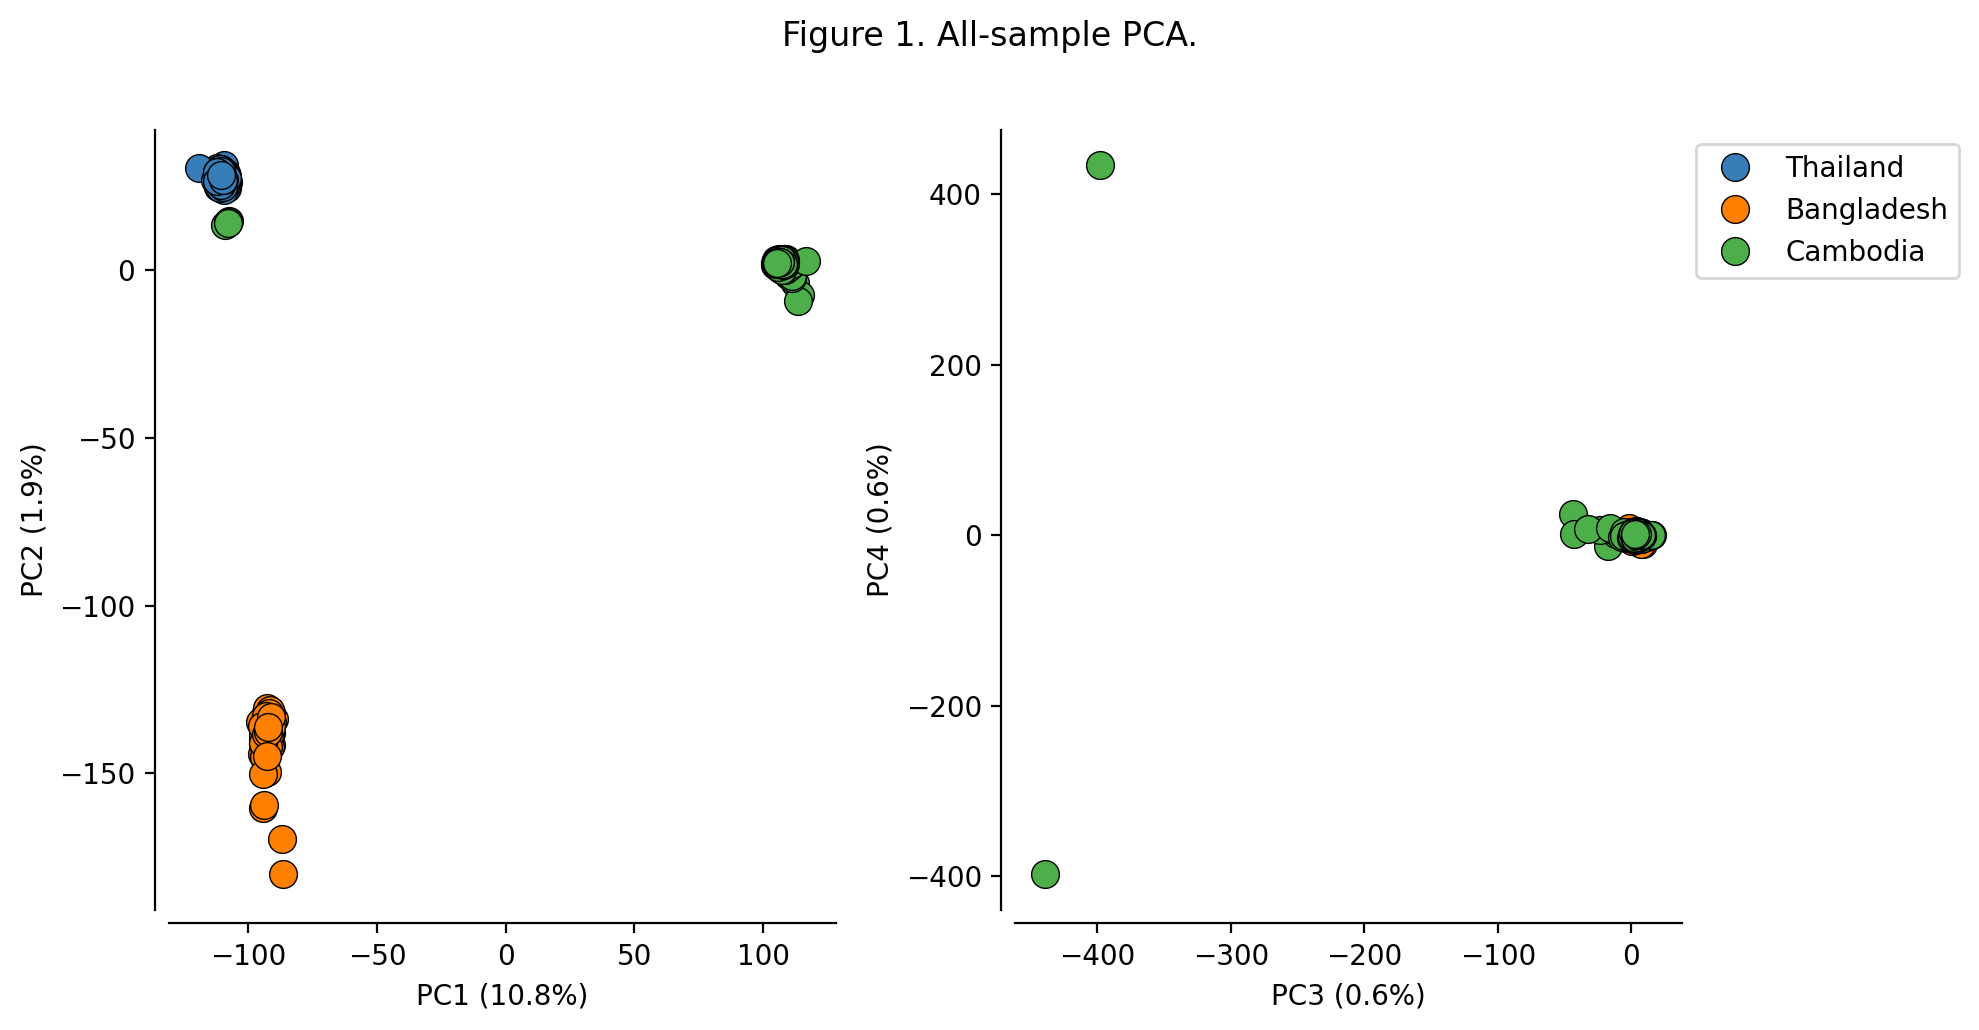

In [10]:
fig_pca(coords, model, 'Figure 1. All-sample PCA.', colourdict = country_colors, df_samples=df_samples)

In [11]:
# Looks like a big imbalance in sample sizes - let's subset to 50 by country
grouped = sequenced_samples_all.groupby('country')

# Apply the sample method to each group
sampled = grouped.apply(lambda x: x.sample(min(len(x), 50)))

# Remove the group keys
sampled = sampled.reset_index(drop=True)

inc_sample_list = sampled['derived_sample_id'].tolist()
#inc_sample_list = [item for item in inc_sample_list if item not in ['DAsgPak010', 'DAsgCPak034', 'Plate2_C2']]
subset_samples = sequenced_samples_all['derived_sample_id'].isin(inc_sample_list) & samples_pass

NameError: name 'sequenced_samples_all' is not defined

In [ ]:
%%time
# Select GTs, run PCA
df_samples_sub = sequenced_samples_all[subset_samples]
#gt = load_gts("KB672490", samples=subset_samples) # load GTs passing site and sample filters
#n_a = return_n_alt(gt) # calculate n_ alt from biallelic sites with a mac > 1
#coords1, model1 = allel.pca(n_a, n_components=10, scaler='patterson') # calculate PCA
fig_pca(coords1, model1, 'Figure 2. Subset (n<50) PCA.', colourdict = country_colors, df_samples = df_samples_sub)

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd


# Define map extent for Southeast Asia + Bangladesh
extent = [90, 110, 5, 24]

# Define colors by country
import matplotlib.cm as cm
import matplotlib.colors as mcolors

countries = df_samples_pass['country'].unique()
color_map = dict(zip(countries, plt.cm.tab10.colors[:len(countries)]))

# Create the plot
fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent)

# Add features
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#c6dbef')
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='gray')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.RIVERS, edgecolor='#3182bd')

# Plot each point colored by country
for _, row in df_samples_pass.iterrows():
    ax.scatter(row['longitude'], row['latitude'],
               color=color_map[row['country']],
               s=60, edgecolor='black',
               transform=ccrs.PlateCarree(),
               label=row['country'])

# Handle legend without duplicate country labels
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Country")

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Title
#plt.title("Southeast Asia Sample Map Colored by Country (excluding Indonesia)", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
fig_pca(coords1, model1, 'Figure 2. Subset (n<50 p/country) PCA.', colourdict = country_colors, df_samples = df_samples_sub)